In [17]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/review_intelligence'
os.chdir(PROJECT_ROOT)
print("✅ Ready to work!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Ready to work!


In [18]:
!pip install -q nltk contractions

import pandas as pd
import numpy as np
import re
import nltk
import contractions
import matplotlib.pyplot as plt

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

print("✅ All libraries ready!")

✅ All libraries ready!


In [19]:
df = pd.read_csv('data/raw/amazon_reviews.csv')
print(f"✅ Loaded {len(df):,} reviews from Drive")
print(f"Columns: {df.columns.tolist()}")

✅ Loaded 5,000 reviews from Drive
Columns: ['sentiment_label', 'review_title', 'text', 'rating']


In [20]:
print("=== RAW REVIEWS ===\n")

for i, row in df.sample(5, random_state=99).iterrows():
    print(f"Rating: {'⭐' * row['rating']}")
    print(f"Review: {row['text'][:300]}")
    print("-" * 60)

=== RAW REVIEWS ===

Rating: ⭐⭐⭐⭐⭐
Review: This book thus far is a great tool for the college poetry course I am takingIt was in practically perfect Condition.
------------------------------------------------------------
Rating: ⭐⭐⭐⭐⭐
Review: Bought this on a Recommendation, and W.O.W!!From the opening track of Modern Religion through to Norwegian Lillies you are taken on a Beautiful Music Journey!.Better Days bring tears to the Inspirational Eye and paints the most wonderful images on the musical Mind.Circle of Friends just says all you
------------------------------------------------------------
Rating: ⭐⭐⭐⭐⭐
Review: Looking forward to season 3 and hope they continue this series for several more seasons. Great actors and great story.
------------------------------------------------------------
Rating: ⭐⭐⭐⭐⭐
Review: I highly enjoyed Grasp the Stars, and as a previous reviewer pointed out, there are several loose-ends that must mean a second book is in the making. The characters are we

In [21]:
def remove_html(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'&\w+;', ' ', text)
    return text

test = "Great product!<br/>Battery life is <b>amazing</b> &amp; worth the price"
print("Before:", test)
print("After: ", remove_html(test))
print()

Before: Great product!<br/>Battery life is <b>amazing</b> &amp; worth the price
After:  Great product! Battery life is  amazing    worth the price



In [22]:
def expand_contractions(text):
    return contractions.fix(text)

test = "I can't believe it won't charge — it isn't what they advertised"
print("Before:", test)
print("After: ", expand_contractions(test))
print()

Before: I can't believe it won't charge — it isn't what they advertised
After:  I cannot believe it will not charge — it is not what they advertised



In [23]:
def to_lowercase(text):
    return text.lower()

test = "The BATTERY LIFE is Amazing and the Screen Quality is SUPERB"
print("Before:", test)
print("After: ", to_lowercase(test))
print()

Before: The BATTERY LIFE is Amazing and the Screen Quality is SUPERB
After:  the battery life is amazing and the screen quality is superb



In [24]:
def remove_special_chars(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

test = "Absolutely LOVE it!!! 5/5 stars ★★★★★ #BestPurchase @Amazon"
print("Before:", test)
print("After: ", remove_special_chars(test))
print()

Before: Absolutely LOVE it!!! 5/5 stars ★★★★★ #BestPurchase @Amazon
After:  Absolutely LOVE it 5 5 stars BestPurchase Amazon



In [25]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [word for word in words if word not in stop_words]
    return ' '.join(filtered)

test = "the battery life is really good and the sound quality is also very nice"
print("Before:", test)
print("After: ", remove_stopwords(test))
print()

Before: the battery life is really good and the sound quality is also very nice
After:  battery life really good sound quality also nice



In [26]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """
    NLTK's pos_tag returns tags in 'Treebank' format like 'VBG', 'NN', 'JJ'.
    WordNetLemmatizer uses a simpler format: 'v' for verb, 'n' for noun,
    'a' for adjective, 'r' for adverb.

    This function acts as a translator between the two systems.
    Without this translation, the lemmatizer cannot use the POS information.
    """
    if treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

AUXILIARY_VERBS = {
    'is', 'are', 'was', 'were', 'am', 'been', 'being',
    'do', 'does', 'did',
    'have', 'has', 'had',
    'will', 'would', 'could', 'should', 'might', 'may',
    'shall', 'must', 'can', 'need', 'dare'
}

def lemmatize_with_pos(text):
    """
    POS-aware lemmatization that intelligently skips auxiliary verbs.

    The key improvement over the previous version: before lemmatizing
    any word, we check whether it is an auxiliary verb. If it is, we
    leave it completely unchanged. Only content words (main verbs,
    nouns, adjectives, adverbs) get lemmatized.
    """
    words = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(words)

    lemmatized_words = []
    for word, tag in pos_tags:

        if word.lower() in AUXILIARY_VERBS:
            lemmatized_words.append(word)
            continue

        if len(word) <= 2:
            lemmatized_words.append(word)
            continue

        wordnet_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=wordnet_pos)
        lemmatized_words.append(lemma)

    return ' '.join(lemmatized_words)

In [27]:
# ── FUNCTION 7: Remove very short reviews ────────────────────────────────
# Reviews with fewer than 5 words after cleaning are essentially useless
# "Great product" or "Does not work" gives us nothing to extract aspects from
# We will filter these out rather than trying to process them

def is_long_enough(text, min_words=5):
    return len(text.split()) >= min_words

# Test
print(is_long_enough("Great!"))           # False — too short
print(is_long_enough("Battery life is amazing and it charges quickly"))  # True

False
True


In [28]:
def preprocess_for_transformers(text):
    """
    Version 1: For BERT-based models on Day 3 and Day 4.

    Keeps punctuation because transformers use ! and ? as sentiment signals.
    Keeps stopwords because BERT needs them for grammatical understanding.
    Only removes noise that models genuinely cannot use (HTML, symbols).
    """
    if pd.isna(text) or text == '':
        return ''

    text = str(text)
    text = remove_html(text)           # remove <br/>, &amp; — not real English
    text = expand_contractions(text)   # can't → cannot, for consistent tokenization
    text = text.lower()                # normalize casing — BERT treats LOVE == love
    text = ' '.join(text.split())      # collapse extra whitespace and newlines

    return text

raw = "This product is TERRIBLE!!! <br/> Can't believe it won't last more than 2 hours. The batteries are draining constantly &amp; the screens keep flickering!!"
cleaned = preprocess_for_transformers(raw)
print("RAW:")
print(raw)
print("\nCLEANED:")
print(cleaned)

RAW:
This product is TERRIBLE!!! <br/> Can't believe it won't last more than 2 hours. The batteries are draining constantly &amp; the screens keep flickering!!

CLEANED:
this product is terrible!!! cannot believe it will not last more than 2 hours. the batteries are draining constantly the screens keep flickering!!


In [29]:
def preprocess_for_statistics(text):
    """
    Version 2: For word clouds, frequency charts, topic modeling on Day 5-6.

    Removes punctuation because "battery." and "battery" should be counted
    as the same word. Removes stopwords because "the", "and", "is" would
    dominate all charts and hide the meaningful product-related words.
    """
    if pd.isna(text) or text == '':
        return ''
    text = str(text)
    text = remove_html(text)
    text = expand_contractions(text)
    text = to_lowercase(text)
    text = remove_special_chars(text)
    text = lemmatize_with_pos(text)
    text = remove_stopwords(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [30]:
print("⏳ Creating transformer-ready text (stopwords + punctuation kept)...")
df['text_for_models'] = df['text'].progress_apply(preprocess_for_transformers)

print("\n⏳ Creating statistics-ready text (stopwords + punctuation removed)...")
df['text_for_stats'] = df['text'].progress_apply(preprocess_for_statistics)

# Filter reviews that became too short after cleaning
# A review with fewer than 5 words after cleaning has no useful content
original_count = len(df)
df = df[df['text_for_models'].apply(lambda x: len(x.split()) >= 5)]
df = df.reset_index(drop=True)
removed = original_count - len(df)

print(f"\n✅ Done! Removed {removed} reviews that were too short after cleaning.")
print(f"Reviews remaining: {len(df):,}")

⏳ Creating transformer-ready text (stopwords + punctuation kept)...


100%|██████████| 5000/5000 [00:00<00:00, 7196.65it/s]



⏳ Creating statistics-ready text (stopwords + punctuation removed)...


100%|██████████| 5000/5000 [00:35<00:00, 140.63it/s]


✅ Done! Removed 0 reviews that were too short after cleaning.
Reviews remaining: 5,000


In [31]:
save_path = 'data/processed/amazon_reviews_cleaned.csv'

# Check if the file already exists, and if so, remove it
if os.path.exists(save_path):
    os.remove(save_path)
    print(f"⚠️ Existing cleaned dataset removed: {save_path}")

df.to_csv(save_path, index=False)
print(f"✅ Cleaned dataset saved to: {save_path}")

✅ Cleaned dataset saved to: data/processed/amazon_reviews_cleaned.csv


In [32]:
print("=== BEFORE vs AFTER — VERIFYING ALL FIXES ===\n")

for i, (_, row) in enumerate(df.sample(5, random_state=7).iterrows(), 1):
    print(f"Review {i}:")
    print(f"  ORIGINAL:         {str(row['text'])[:200]}")
    print(f"  FOR MODELS:       {row['text_for_models'][:200]}")
    print(f"  FOR STATISTICS:   {row['text_for_stats'][:200]}")
    print()

# What we should see:
# FOR MODELS: natural-sounding English, "is" stays as "is", punctuation present
# FOR STATISTICS: key concepts only, no stopwords, no punctuation

=== BEFORE vs AFTER — VERIFYING ALL FIXES ===

Review 1:
  ORIGINAL:         One of the worst movies ever made. Watching Sean Connery in a bear suit while running around was ugly. The pair (Ralph Fiennes and Uma Thurman) have no chemistry what so ever and talk like their Engli
  FOR MODELS:       one of the worst movies ever made. watching sean connery in a bear suit while running around was ugly. the pair (ralph fiennes and uma thurman) have no chemistry what so ever and talk like their engli
  FOR STATISTICS:   one bad movie ever make watch sean connery bear suit run around ugly pair ralph fiennes uma thurman chemistry ever talk like english horrible fight people umbrella fight mechanical bee chase car excit

Review 2:
  ORIGINAL:         WHAT CAN YOU SAY - IT HAS A GOOD CAST, AND A GOOD PLOT WHICH TRANSLATES INTO A FANTASTIC MOVIE. BUY IT !!!
  FOR MODELS:       what can you say - it has a good cast, and a good plot which translates into a fantastic movie. buy it !!!
  FOR STATISTIC

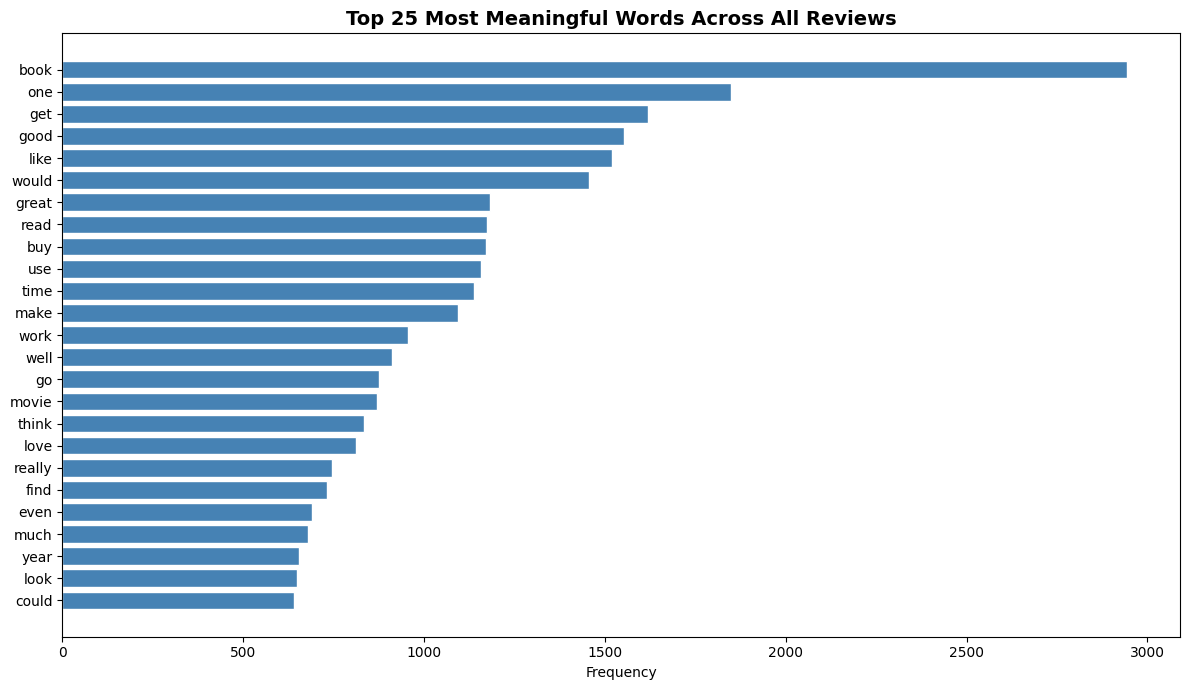

In [33]:
from collections import Counter
import matplotlib.pyplot as plt

# Use the statistics version — this is what frequency analysis needs
all_words = ' '.join(df['text_for_stats'].dropna()).split()
word_freq = Counter(all_words).most_common(25)

words, counts = zip(*word_freq)

plt.figure(figsize=(12, 7))
plt.barh(list(words)[::-1], list(counts)[::-1], color='steelblue', edgecolor='white')
plt.title("Top 25 Most Meaningful Words Across All Reviews",
          fontsize=14, fontweight='bold')
plt.xlabel("Frequency")
plt.tight_layout()
plt.savefig('outputs/top_words_after_cleaning.png', dpi=150)
plt.show()